In [1]:
from google.colab import files

uploaded = files.upload()

Saving users_200.csv to users_200.csv


In [2]:
from google.colab import files

uploaded = files.upload()

Saving courses.csv to courses.csv


In [3]:
import pandas as pd

users = pd.read_csv("users_200.csv")
courses = pd.read_csv("courses.csv")

print(users.head())
print(courses.head())

   user_id     name     interest_1   interest_2   interest_3
0        1   Kavya1             AI      Fitness       Travel
1        2   Sneha2  Cybersecurity       Gaming       Gaming
2        3  Ananya3            Art  Photography  Photography
3        4  Vikram4             AI       Coding      Fitness
4        5  Nikhil5         Travel           AI       Gaming
   course_id         course_name          tag_1        tag_2       tag_3
0        101    Travel Creator 1         Travel  Photography     Content
1        102     Cyber Warrior 2  Cybersecurity   Networking    Security
2        103      UI UX Design 3         Design          Art  Creativity
3        104  Game Development 4         Gaming       Coding       Unity
4        105    Cloud Engineer 5          Cloud          AWS      DevOps


In [4]:
user_id = int(input("Enter User ID: "))

user = users[users["user_id"] == user_id].iloc[0]

user_interests = {
    user["interest_1"],
    user["interest_2"],
    user["interest_3"]
}

recommendations = []

for _, course in courses.iterrows():
    course_tags = {
        course["tag_1"],
        course["tag_2"],
        course["tag_3"]
    }

    score = len(user_interests.intersection(course_tags))

    if score > 0:
        recommendations.append(
            (course["course_name"], score)
        )

recommendations.sort(key=lambda x: x[1], reverse=True)

print("\nRecommended Courses:")
for course, score in recommendations[:10]:
    print(f"{course} - Score: {score}")

Enter User ID: 5

Recommended Courses:
Travel Creator 1 - Score: 1
Game Development 4 - Score: 1
AI Mastery 7 - Score: 1
Game Development 8 - Score: 1
Travel Creator 11 - Score: 1
AI Mastery 28 - Score: 1
AI Mastery 34 - Score: 1
Travel Creator 38 - Score: 1
AI Mastery 44 - Score: 1
Game Development 46 - Score: 1


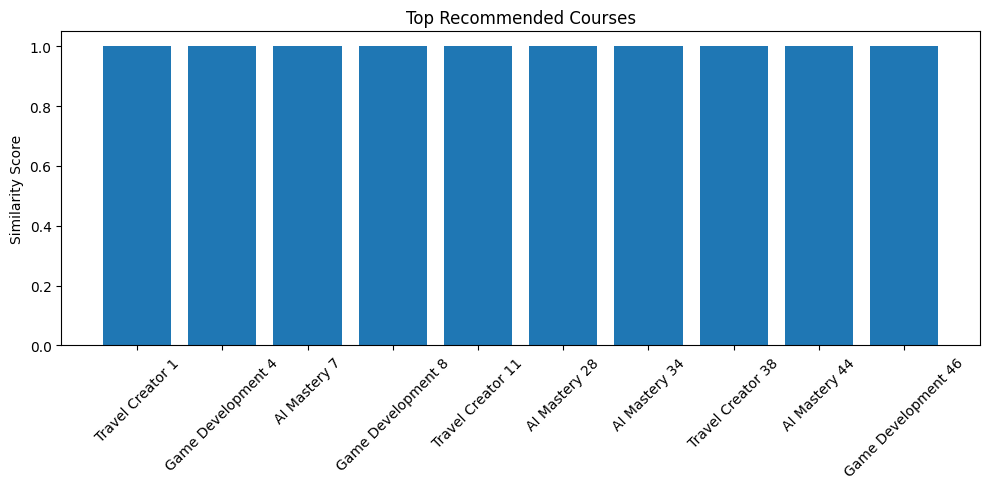

In [5]:
import matplotlib.pyplot as plt

top_courses = recommendations[:10]

names = [x[0] for x in top_courses]
scores = [x[1] for x in top_courses]

plt.figure(figsize=(10,5))
plt.bar(names, scores)
plt.xticks(rotation=45)
plt.title("Top Recommended Courses")
plt.ylabel("Similarity Score")
plt.tight_layout()
plt.show()

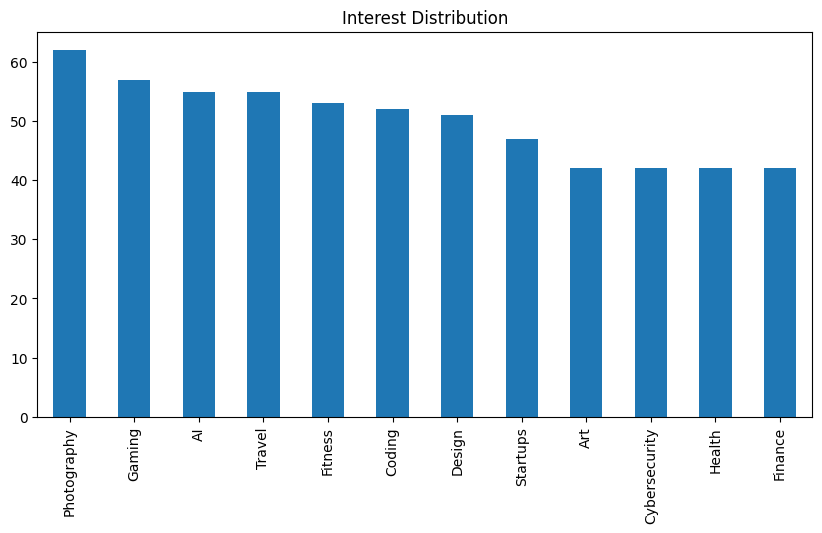

In [6]:
import matplotlib.pyplot as plt

all_interests = []

for col in ["interest_1","interest_2","interest_3"]:
    all_interests.extend(users[col])

import pandas as pd

counts = pd.Series(all_interests).value_counts()

plt.figure(figsize=(10,5))
counts.plot(kind="bar")
plt.title("Interest Distribution")
plt.show()

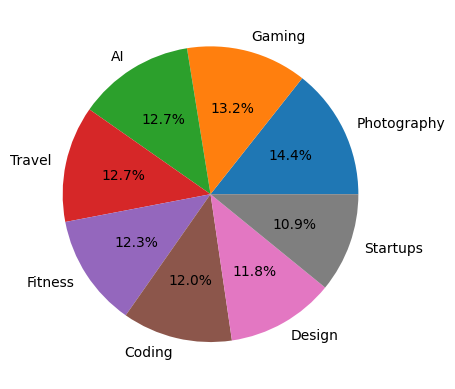

In [7]:
counts.head(8).plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.show()
